In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
!pip install scipy PyWavelets -q

import requests, io
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import scipy.io as iomat
import helpers
from TIMBRE import TIMBRE
from analysis import plot_arm, plot_arm_pinv
import pywt

# --- Load data ---
url = "https://api.figshare.com/v2/articles/24757638"
files = requests.get(url).json()['files']
f = next(x for x in files if x['name'] == 'data04.mat')
data = iomat.loadmat(io.BytesIO(requests.get(f['download_url']).content))

# --- Preprocess ---
LFPs = helpers.filter_data(data['lfps'], 2, fs=25, use_hilbert=True)
test_inds, train_inds = helpers.test_train(data['lapID'], which_phase=1, n_folds=5, which_fold=0)
wLFPs, U, Xv = helpers.whiten(LFPs, train_inds)
print(f"LFPs shape: {LFPs.shape}, electrodes: {LFPs.shape[1]}")

In [ ]:
m0,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=0)
m3,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=3)
m6,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)

arm_nodes_m0 = helpers.node_arm_map(m0, wLFPs, test_inds, data['lapID'], top_k=1)
arm_nodes_m3 = helpers.node_arm_map(m3, wLFPs, test_inds, data['lapID'], top_k=1)
arm_nodes_m6 = helpers.node_arm_map(m6, wLFPs, test_inds, data['lapID'], top_k=2)

In [ ]:
t3 = helpers.get_complex_weights(m3, 3)
t6 = helpers.get_complex_weights(m6, 6)

In [ ]:
arms = 3
t0 = helpers.get_complex_weights(m0)

for i in range(arms):
    ARM = np.where((data['lapID'][:, 1] == i) & (data['lapID'][:, 3] == 1))[0] #trial-phase1
    print(np.mean(np.abs(((LFPs[ARM] @ (np.conj(U.T) / Xv) @ np.conj(t0)))) ,axis = 0))

In [31]:
arms = 3
#plt.plot(np.abs(LFPs[data['lapID'][:, 3] == 1] @ (np.conj(U_1.T) / Xv_1) @ np.conj(t0)))

for i in range(arms):
    ARM = np.where((data['lapID'][:, 1] == i) & (data['lapID'][:, 3] == 1))[0] #trial-phase1
    print(np.mean(np.abs(((LFPs[ARM] @ (np.conj(U.T) / Xv) @ np.conj(t3)))) ,axis = 0))

[1.78261336 0.40093116 0.40853693]
[0.37851205 1.74499827 0.44642851]
[0.45102055 0.46566849 1.66635643]


In [32]:
arms = 3
t0 = get_complex_weights(m0,0)
#plt.plot(np.abs(LFPs[data['lapID'][:, 3] == 1] @ (np.conj(U_1.T) / Xv_1) @ np.conj(t0)))

for i in range(arms):
    ARM = np.where((data['lapID'][:, 1] == i) & (data['lapID'][:, 3] == 1))[0] #trial-phase1
    print(np.mean(np.abs(((LFPs[ARM] @ (np.conj(U.T) / Xv) @ np.conj(t6)))) ,axis = 0))

[1.59731423 1.47481678 0.43543185 0.43374239 0.43320501 0.42230947]
[0.3892293  0.37369183 1.58879393 0.42336699 0.46156421 1.52659034]
[0.45977061 0.47386299 0.47233756 1.75410711 1.2584651  0.47193831]


In [33]:
#eSpace3 = U @ t3 
#eSpace6 = U @ t6 

eSpace3 = (np.conj(U.T) / Xv) @ np.conj(t3)
eSpace6 = (np.conj(U.T) / Xv) @ np.conj(t6)
eSpace0 = (np.conj(U.T) / Xv) @ np.conj(t0)
eSpace0.shape

(192, 3)

In [ ]:
plot_arm(0, eSpace0, eSpace3, eSpace6, arm_nodes_m0, arm_nodes_m3, arm_nodes_m6)

In [ ]:
plot_arm_pinv(0, eSpace0, eSpace3, eSpace6, arm_nodes_m0, arm_nodes_m3, arm_nodes_m6)

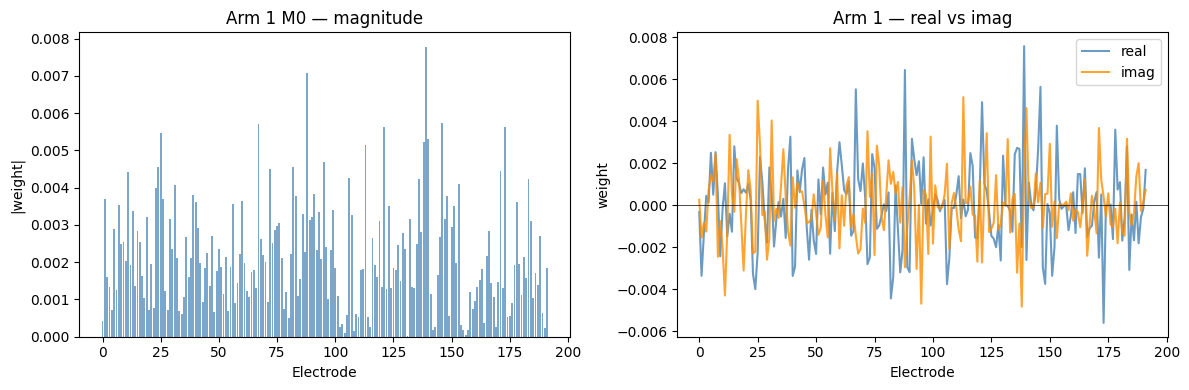

In [38]:
arm_idx = 0
node0   = arm_nodes_m0[arm_idx][0]

f = eSpace0[:, node0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# magnitude
axes[0].bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
axes[0].set_title(f'Arm {arm_idx+1} M0 — magnitude')
axes[0].set_xlabel('Electrode')
axes[0].set_ylabel('|weight|')

# real vs imaginary
axes[1].plot(f.real, color='steelblue', alpha=0.8, label='real')
axes[1].plot(f.imag, color='darkorange', alpha=0.8, label='imag')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title(f'Arm {arm_idx+1} — real vs imag')
axes[1].set_xlabel('Electrode')
axes[1].set_ylabel('weight')
axes[1].legend()

plt.tight_layout()
plt.show()

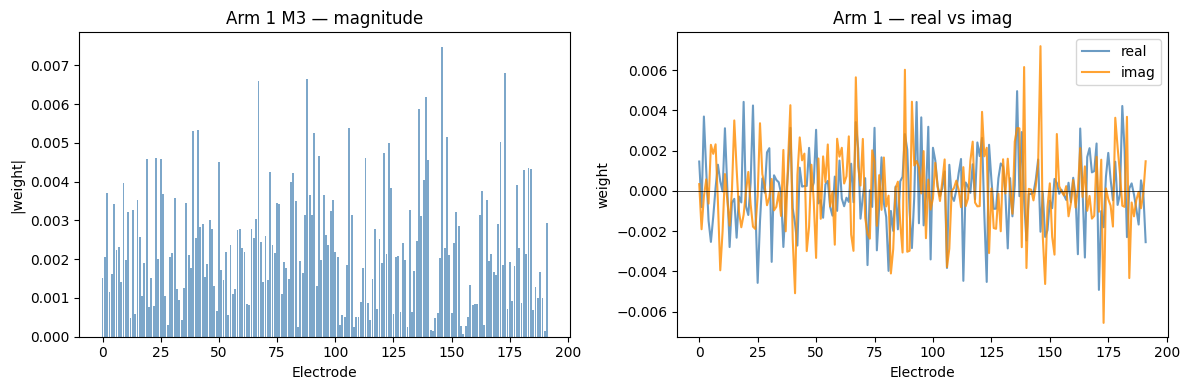

In [39]:
arm_idx = 0
node0   = arm_nodes_m3[arm_idx][0]

f = eSpace3[:, node0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# magnitude
axes[0].bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
axes[0].set_title(f'Arm {arm_idx+1} M3 — magnitude')
axes[0].set_xlabel('Electrode')
axes[0].set_ylabel('|weight|')

# real vs imaginary
axes[1].plot(f.real, color='steelblue', alpha=0.8, label='real')
axes[1].plot(f.imag, color='darkorange', alpha=0.8, label='imag')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title(f'Arm {arm_idx+1} — real vs imag')
axes[1].set_xlabel('Electrode')
axes[1].set_ylabel('weight')
axes[1].legend()

plt.tight_layout()
plt.show()

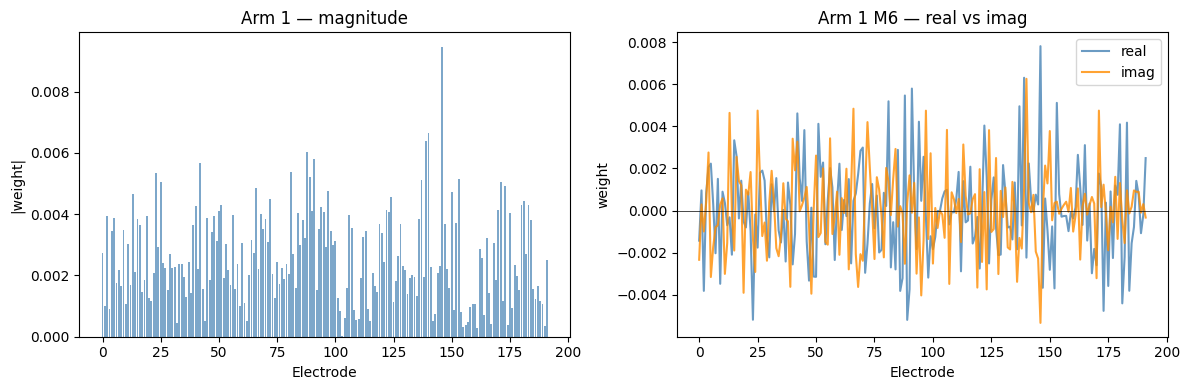

In [40]:
arm_idx = 0
node0   = arm_nodes_m6[arm_idx][0]

f = eSpace6[:, node0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# magnitude
axes[0].bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
axes[0].set_title(f'Arm {arm_idx+1} — magnitude')
axes[0].set_xlabel('Electrode')
axes[0].set_ylabel('|weight|')

# real vs imaginary
axes[1].plot(f.real, color='steelblue', alpha=0.8, label='real')
axes[1].plot(f.imag, color='darkorange', alpha=0.8, label='imag')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title(f'Arm {arm_idx+1} M6 — real vs imag')
axes[1].set_xlabel('Electrode')
axes[1].set_ylabel('weight')
axes[1].legend()

plt.tight_layout()
plt.show()

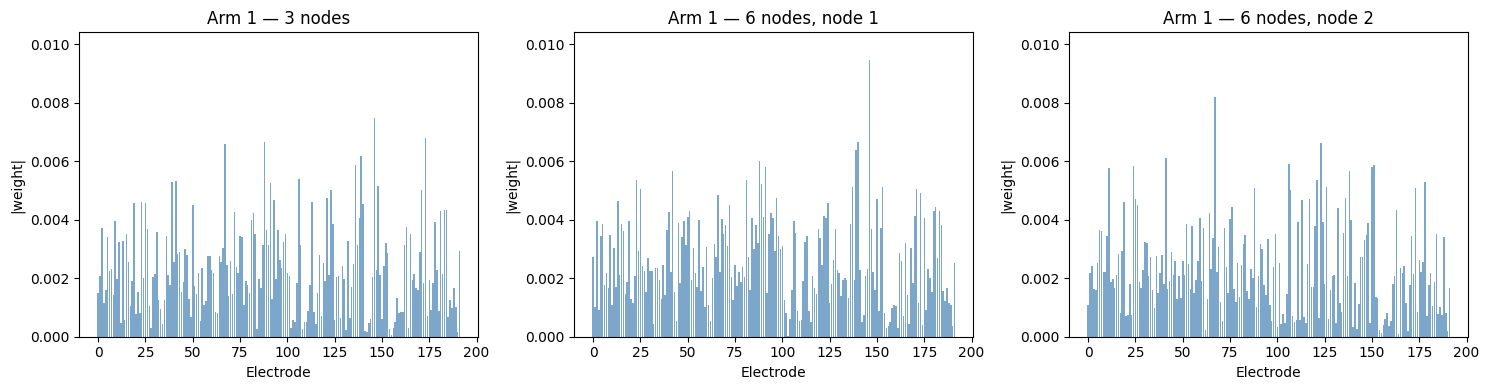

In [37]:
arm_idx = 0  

node3  = arm_nodes_m3[arm_idx][0]
n0, n1 = arm_nodes_m6[arm_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

filters = [
    (eSpace3[:, node3],  f'Arm {arm_idx+1} — 3 nodes'),
    (eSpace6[:, n0],     f'Arm {arm_idx+1} — 6 nodes, node 1'),
    (eSpace6[:, n1],     f'Arm {arm_idx+1} — 6 nodes, node 2'),
]

vmax = max(np.max(np.abs(f)) for f, _ in filters)

for ax, (f, title) in zip(axes, filters):
    ax.bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
    ax.set_ylim(0, vmax * 1.1)
    ax.set_title(title)
    ax.set_xlabel('Electrode')
    ax.set_ylabel('|weight|')

plt.tight_layout()
plt.show()

In [8]:
COL_TRIAL = 0
COL_ARM   = 1
COL_PHASE = 3
COL_X     = 4
COL_Y     = 5
N_ARMS    = 3

def complex_activations(wLFPs, model, n_nodes, helpers):
    """
    Raw complex hidden-layer activations, pre-abs / pre-softmax.
    Mirrors `acts6 = raw[:, :n] + 1j*raw[:, n:]` from your recap.
 
    Returns: (T, n_nodes) complex
    """
    raw = helpers.layer_output(wLFPs, model, 0)        # (T, 2*n_nodes) real
    return raw[:, :n_nodes] + 1j * raw[:, n_nodes:]

def position_bins(lapID, n_bins, which_phase):
    """
    For each arm, project that arm's (x,y) onto its principal axis, rescale to
    [0,1], orient so the reward-port end (where phase==2 concentrates) is at 1,
    and assign each timepoint an integer bin in [0, n_bins).
 
    Returns: posBin (T,) int, with -1 where the sample is not used
             (wrong phase, or off-maze).
    """
    x = lapID[:, COL_X].astype(float)
    y = lapID[:, COL_Y].astype(float)
    arm = lapID[:, COL_ARM].astype(int)
    phase = lapID[:, COL_PHASE].astype(int)
 
    posBin = np.full(len(arm), -1, dtype=int)
    use = (phase == which_phase) & (arm >= 0)          # exclude off-maze (-1)
 
    for a in range(N_ARMS):
        sel = use & (arm == a)
        if sel.sum() < 2:
            continue
        xy = np.column_stack([x[sel], y[sel]])
        xy_c = xy - xy.mean(0)
        # principal axis of this arm
        _, _, vt = np.linalg.svd(xy_c, full_matrices=False)
        proj = xy_c @ vt[0]
 
        # orient so the port end -> high values. Port = where phase==2 sits.
        port = (lapID[:, COL_PHASE].astype(int) == 2) & (arm == a)
        if port.any():
            port_xy = np.column_stack([x[port], y[port]]) - xy.mean(0)
            if (port_xy @ vt[0]).mean() < proj.mean():
                proj = -proj
 
        proj = (proj - proj.min()) / (np.ptp(proj) + 1e-12)
        b = np.clip((proj * n_bins).astype(int), 0, n_bins - 1)
        posBin[sel] = b
 
    return posBin

def resp_vs_pos(acts, lapID, n_bins, which_phase, fill_nan_from_prev=True):
    """
    acts : (T, n_nodes) complex hidden activations
    Returns respMat: (n_nodes, n_trials, n_bins, n_arms) complex, nan where empty.
    """
    n_nodes = acts.shape[1]
    trial = lapID[:, COL_TRIAL].astype(int)
    arm = lapID[:, COL_ARM].astype(int)
    phase = lapID[:, COL_PHASE].astype(int)
    posBin = position_bins(lapID, n_bins, which_phase)
 
    n_trials = int(trial.max()) + 1
    respMat = np.full((n_nodes, n_trials, n_bins, N_ARMS), np.nan, dtype=complex)
 
    use = (phase == which_phase) & (arm >= 0) & (posBin >= 0)
    idx_t = trial[use]
    idx_p = posBin[use]
    idx_a = arm[use]
 
    # accumulate complex mean per (trial, pos, arm) bin, per node
    # (numpy has no complex bincount mean, so sum/count manually)
    for k in range(n_nodes):
        vals = acts[use, k]
        # flatten (trial,pos,arm) -> single index
        flat = (idx_t * n_bins + idx_p) * N_ARMS + idx_a
        size = n_trials * n_bins * N_ARMS
        s = np.zeros(size, dtype=complex)
        c = np.zeros(size, dtype=float)
        np.add.at(s, flat, vals)
        np.add.at(c, flat, 1.0)
        with np.errstate(invalid="ignore", divide="ignore"):
            mean = np.where(c > 0, s / np.maximum(c, 1), np.nan)
        respMat[k] = mean.reshape(n_trials, n_bins, N_ARMS)
 
    # fill empty bins from the previous trial (as in respVsPos.m)
    if fill_nan_from_prev:
        for i in range(1, n_trials):
            for j in range(N_ARMS):
                nan_here = np.isnan(respMat[0, i, :, j])
                respMat[:, i, nan_here, j] = respMat[:, i - 1, nan_here, j]
 
    return respMat

# 4) superImp: collapse nodes -> one RGB image (winner-take-all, brightness=mag)
# ----------------------------------------------------------------------------
def super_imp(x, rad=0.0, max_val=None, num_col=None):
    """
    Port of superImp.m.
 
    x : (n_components, H, W) real, nonneg magnitudes
        (pass np.abs(respMat_slice); H=trial, W=position)
    rad : gaussian smoothing sigma (0 = none)
    max_val : fixed normalizer; default = each component's 99.9th percentile
    num_col : hue spread. None -> evenly spaced i/n. int>0 -> mod((i/n)*num_col,1).
 
    Returns: RGB image (H, W, 3) in [0,1].
    """
    x = np.array(x, dtype=float, copy=True)
    n = x.shape[0]
 
    if rad:
        from scipy.ndimage import gaussian_filter
        for i in range(n):
            x[i] = gaussian_filter(x[i], sigma=rad, truncate=2.5)
 
    for i in range(n):
        if max_val is None:
            denom = np.nanpercentile(x[i], 99.9)
        else:
            denom = max_val
        x[i] = x[i] / (denom + 1e-12)
 
    # hue per component
    if num_col is None:
        cols = (np.arange(n) + 1) / n
    else:
        cols = np.mod((np.arange(n) + 1) / n * num_col, 1.0)
 
    x = np.abs(x)
    x = np.clip(x, 0, 1)
    x = np.nan_to_num(x, nan=0.0)
 
    b = np.argmax(x, axis=0)                # winning component per pixel
    a = np.max(x, axis=0)                   # winner magnitude
    a = np.clip(a, 0, 1)
 
    H, W = a.shape
    hsv = np.zeros((H, W, 3))
    for i in range(n):
        m = (b == i)
        hsv[m, 0] = cols[i]                 # hue = node identity
    hsv[:, :, 1] = 1.0                      # saturation
    hsv[:, :, 2] = np.where(a > 0, 0.4 + 0.6 * a, 0.0)                         # value = winner magnitude
 
    return hsv_to_rgb(hsv)

def session_image(respMat, rad=1.0, num_col=None, gap=2):
    """
    respMat : (n_nodes, n_trials, n_bins, n_arms) complex
    Returns RGB (n_trials, n_arms*n_bins + gaps, 3) with white gaps between arms.
    """
    n_nodes, n_trials, n_bins, n_arms = respMat.shape
    arm_imgs = []
    for a in range(n_arms):
        sl = np.abs(respMat[:, :, :, a])        # (n_nodes, trial, pos)
        arm_imgs.append(super_imp(sl, rad=rad, num_col=num_col))
 
    white = np.ones((n_trials, gap, 3))
    pieces = []
    for a in range(n_arms):
        pieces.append(arm_imgs[a])
        if a < n_arms - 1:
            pieces.append(white)
    return np.concatenate(pieces, axis=1)

def plot_single(wLFPs, model, n_nodes, lapID, helpers,
                n_bins=50, which_phase=1, rad=1.0, num_col=None, title=None):
    acts = complex_activations(wLFPs, model, n_nodes, helpers)
    respMat = resp_vs_pos(acts, lapID, n_bins, which_phase)
    img = session_image(respMat, rad=rad, num_col=num_col)
 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(img, aspect="auto", interpolation="nearest", origin="upper")
    ax.set_xlabel("Position on each arm")
    ax.set_ylabel("Trial number")
    ax.set_title(title or f"{n_nodes}-node  (phase={which_phase})")
    plt.tight_layout()
    return fig, respMat
 
 
def plot_grid(sessions, n_nodes, helpers,
              n_bins=50, which_phase=1, rad=1.0, num_col=None):
    """
    sessions : list of dicts, each like
        {'wLFPs': ..., 'model': ..., 'lapID': ...}
    Produces the 2x2 figure.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for s, ax in zip(sessions, axes.ravel()):
        acts = complex_activations(s["wLFPs"], s["model"], n_nodes, helpers)
        respMat = resp_vs_pos(acts, s["lapID"], n_bins, which_phase)
        img = session_image(respMat, rad=rad, num_col=num_col)
        ax.imshow(img, aspect="auto", interpolation="nearest", origin="upper")
        ax.set_xlabel("Position on each arm")
        ax.set_ylabel("Trial number")
    for i, ax in enumerate(axes.ravel()[:len(sessions)]):
        ax.set_title(f"Session {i + 1}")
    plt.tight_layout()
    return fig

2866/2866 ━━━━━━━━━━━━━━━━━━━━ 1s 302us/step
2866/2866 ━━━━━━━━━━━━━━━━━━━━ 1s 236us/step


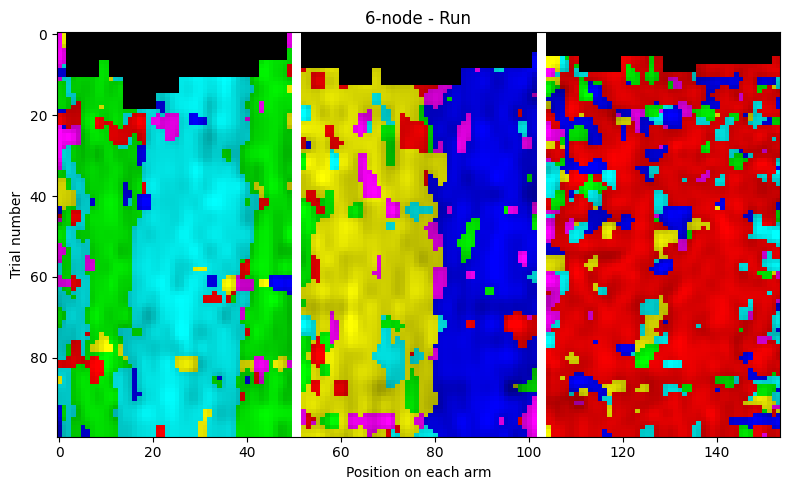

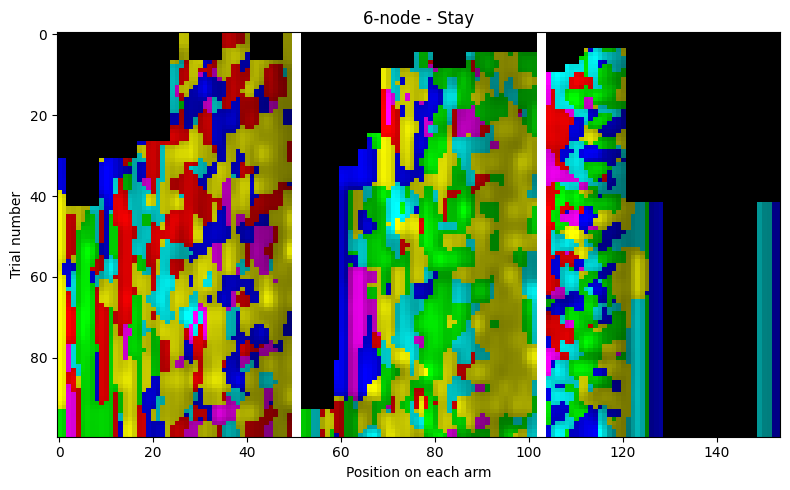

In [9]:
from matplotlib.colors import hsv_to_rgb

fig, respMat = plot_single(wLFPs, m6, 6, data['lapID'], helpers,
                            which_phase=1, title="6-node - Run")

# # same, STAY (expect bands to smear / position axis is weak during stay):
fig, _ = plot_single(wLFPs, m6, 6, data['lapID'], helpers,
                      which_phase=2, title="6-node - Stay")
#
# # 2x2 grid once the single panel looks right:
#sessions = [
#     {'wLFPs': wLFPs1, 'model': m6_s1, 'lapID': data1['lapID']},
#     {'wLFPs': wLFPs2, 'model': m6_s2, 'lapID': data2['lapID']},
#     {'wLFPs': wLFPs3, 'model': m6_s3, 'lapID': data3['lapID']},
#     {'wLFPs': wLFPs4, 'model': m6_s4, 'lapID': data4['lapID']},
# ]
#fig = plot_grid(sessions, 6, helpers, which_phase=1)

plt.show()